# Causal Inference - A New Recommendation System 

## Libraries

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, pairwise_distances_argmin_min
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
from causalinference import CausalModel

ImportError: DLL load failed while importing _smoothers_lowess: The filename or extension is too long.

## Exploratory Data Analysis

1) Overview
2) Data Cleaning
    * Missing Values
    * Ducplicates
3) Categorical Variables
4) Continuous Variables
5) One-Hot Enconding (`Segment`)
6) The Naive Researcher

In [2]:
# 1. Overview

# Lendo o csv e ignorando a primeira coluna
df = pd.read_csv(r"C:\Users\caiov\OneDrive - UCLA IT Services\Documentos\DataScience\Repositories\causal-project\data\synthetic_data_before_after_program.csv", index_col=0)

print("File successfully loaded.")
print(df.head())

print("\nData types and missing values:")
print(df.info())

Arquivo carregado com sucesso.
   user_id  time  treatment   segmento  historico_compras  frequencia_acesso  \
0        1     0          0  frequente         229.829510           3.569780   
1        1     1          0  frequente         229.829510           3.569780   
2        2     0          0       novo         135.665763           1.154105   
3        2     1          0       novo         135.665763           1.154105   
4        3     0          0       novo         224.616911           1.548176   

   engajamento     vendas  
0     6.006856  77.009942  
1     5.730194  56.928141  
2     5.211772  49.664305  
3     5.737937  55.213284  
4     6.197572  40.040737  

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            40000 non-null  int64  
 1   time               40000 non-null  i

In [3]:
# 2. Data Cleaning

#  Missing Values
print("\nMissing values em cada coluna:")
print(df.isnull().sum())
print("--> Não há missing data.")

# Duplicados
print("\nNúmero de linhas duplicadas: ", df.duplicated().sum())
print("--> Não há duplicados.")


Missing values em cada coluna:
user_id              0
time                 0
treatment            0
segmento             0
historico_compras    0
frequencia_acesso    0
engajamento          0
vendas               0
dtype: int64
--> Não há missing data.

Número de linhas duplicadas:  0
--> Não há duplicados.


In [4]:
# 3. Variáveis Categóricas

categorical_columns = df.select_dtypes(include=['object']).columns

# Lista de variáveis categóricas
print("Variáveis Categóricas:")
print(categorical_columns.tolist())


Variáveis Categóricas:
['segmento']


In [5]:
# 4. Variáveis Contínuas

continuous_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Exclude discrete variables (e.g., treatment, time)
continuous_columns = [col for col in continuous_columns if df[col].nunique() > 10]

# Display the list of continuous variables
print("Variáveis Contínuas:")
print(continuous_columns)


Variáveis Contínuas:
['user_id', 'historico_compras', 'frequencia_acesso', 'engajamento', 'vendas']


In [6]:
# 5. One-Hot Encoding

# Perform one-hot encoding for 'segmento', keeping the original column
# Drops the first category (alto_valor) to avoid the dummy variable trap (multicollinearity).
encoded_segments = pd.get_dummies(df['segmento'], prefix='segmento', drop_first=True)

# Add the encoded columns to the dataframe
df = pd.concat([df, encoded_segments], axis=1)

print("Arquivo carregado com sucesso.")
print(df.head())

# Convert boolean columns to integers
df['segmento_frequente'] = df['segmento_frequente'].astype(int)
df['segmento_novo'] = df['segmento_novo'].astype(int)

print("\nData types and missing values:")
print("\nThe base category 'alto_valor' will be represented implicitly.")
print(df.info())

Arquivo carregado com sucesso.
   user_id  time  treatment   segmento  historico_compras  frequencia_acesso  \
0        1     0          0  frequente         229.829510           3.569780   
1        1     1          0  frequente         229.829510           3.569780   
2        2     0          0       novo         135.665763           1.154105   
3        2     1          0       novo         135.665763           1.154105   
4        3     0          0       novo         224.616911           1.548176   

   engajamento     vendas  segmento_frequente  segmento_novo  
0     6.006856  77.009942                True          False  
1     5.730194  56.928141                True          False  
2     5.211772  49.664305               False           True  
3     5.737937  55.213284               False           True  
4     6.197572  40.040737               False           True  

Data types and missing values:

The base category 'alto_valor' will be represented implicitly.
<class 'pandas

In [7]:
# 6. The Naive Researcher
mean_values = df.groupby('treatment')[['engajamento', 'vendas']].mean()

print(mean_values)

# Calculate the average outcome for the treated and control groups
avg_treated_engagement = df[df['treatment'] == 1]['engajamento'].mean()  # Outcome for treated
avg_control_engagement = df[df['treatment'] == 0]['engajamento'].mean()  # Outcome for control

# Calculate the ATE
ATE_engagement = avg_treated_engagement - avg_control_engagement

print("ATE (Average Treatment Effect):", ATE_engagement)

# Calculate the average outcome for the treated and control groups
avg_treated_sales = df[df['treatment'] == 1]['vendas'].mean()  # Outcome for treated
avg_control_sales = df[df['treatment'] == 0]['vendas'].mean()  # Outcome for control

# Calculate the ATE
ATE_sales = avg_treated_sales - avg_control_sales

print("ATE (Average Treatment Effect):", ATE_sales)


           engajamento     vendas
treatment                        
0             5.781908  70.077275
1             7.144201  95.136922
ATE (Average Treatment Effect): 1.3622924746791272
ATE (Average Treatment Effect): 25.05964671828984


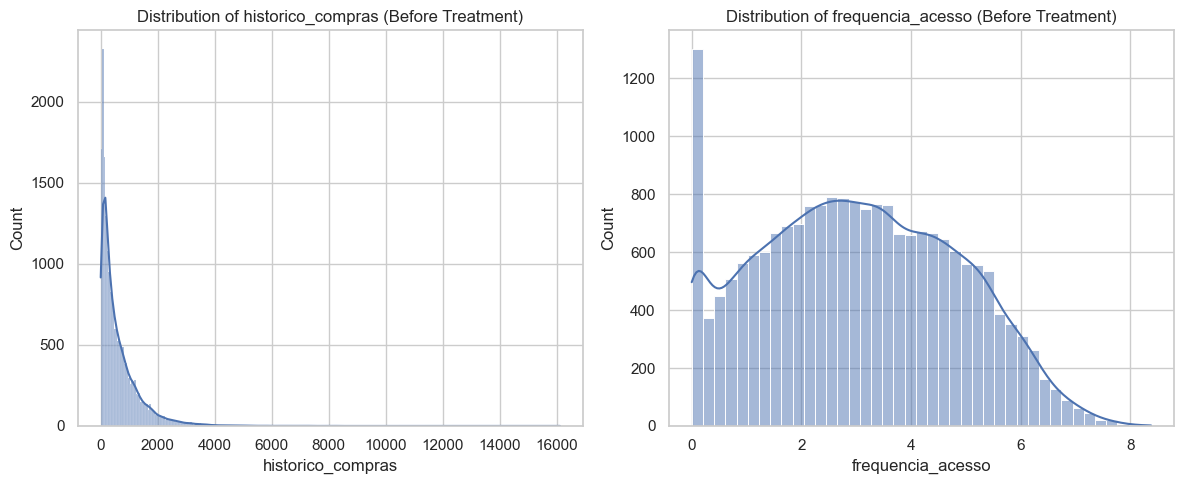

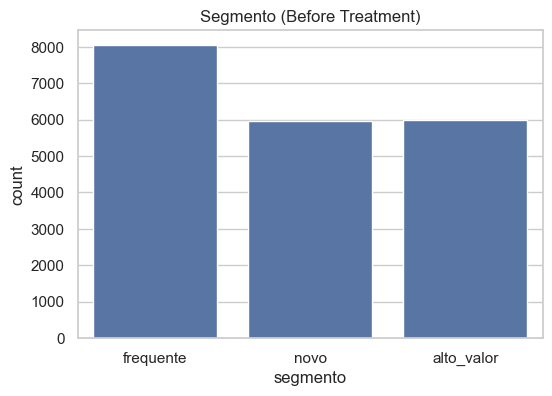

In [14]:
# Marginal Distributions

# This code allow you to:
# Calculate and visualize the marginal distribution of treatment and confounders.

treatment_col = 'treatment'
confounders = ['segmento', 'historico_compras', 'frequencia_acesso']

# Filter data for users before treatment (time = 0)
df_pre_treatment = df[df['time'] == 0]

# Set plot style
sns.set(style="whitegrid")

# Plot histograms for continuous variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_pre_treatment['historico_compras'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of historico_compras (Before Treatment)')

sns.histplot(df_pre_treatment['frequencia_acesso'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of frequencia_acesso (Before Treatment)')

plt.tight_layout()
plt.show()

# Plot bar plot for segmento
plt.figure(figsize=(6, 4))
sns.countplot(x='segmento', data=df_pre_treatment)
plt.title('Segmento (Before Treatment)')
plt.show()


# # Marginal Distribution for Treatment
# treatment_distribution = df[treatment_col].value_counts(normalize=True)
# print("Treatment Assignment Distribution:")
# print(treatment_distribution)

# # Visualize treatment assignment
# sns.barplot(
#     x=treatment_distribution.index,
#     y=treatment_distribution.values,
#     hue=treatment_distribution.index,  # Assign x to hue
#     palette="viridis",
#     dodge=False,  # Avoid separation of bars
#     legend=False  # Remove unnecessary legend
# )
# plt.title("Treatment Assignment Distribution")
# plt.xlabel("Treatment")
# plt.ylabel("Proportion")
# plt.show()

# # Marginal Distributions for Confounders
# for confounder in confounders:
#     print(f"Marginal Distribution for {confounder}:")
#     print(df[confounder].describe())  # Summary stats
#     sns.histplot(df[confounder], kde=False, color="blue", bins=20)
#     plt.title(f"Distribution of {confounder}")
#     plt.xlabel(confounder)
#     plt.ylabel("Frequency")
#     plt.show()

### Analysis (Marginal Distribution part)

1. **Treatment Assignment Distribution**

* Approximately 90.96% of users are in the control group (treatment = 0), and only 9.04% are in the treatment group (treatment = 1).
* **Implication**: The treatment group is significantly smaller, which may affect the statistical power of comparisons and make it harder to detect effects unless they are large. **This imbalance could also exacerbate confounding issues**.

2. **Marginal Distribution of `segmento`**

* The most frequent segment is `frequente` (40.28% of users), followed by `novo` (29.99%) and `alto_valor` (29.73%).
* **Implication**: Treatment assignment by `segmento` is skewed (see below), **indicating potential confounding** since segment membership might influence the outcome variables (`engajamento` and `vendas`).

3. **Marginal Distributions for `historico_compras` and `frequencia_acesso`**

* `historico_compras`:
    * Mean: 635.99, Median: 388.47, with a wide range (Min: 6.05, Max: 16,114.11).
    * Distribution shows a right skew, typical of purchase data with high spenders driving the upper range.

* `frequencia_acesso`:
    * Mean: 3.03 visits/week, Median: 2.99 visits/week, with a maximum of 8.38 visits.
    * Distribution is more compact but slightly skewed.

* **Implication**: 
    * Both variables are continuous and exhibit variability, which could interact with treatment assignment.
    * `historico_compras` is a **potential confounder** since users with higher purchase histories are more likely to receive the treatment. Additionally, `historico_compras` likely impacts sales and engagement directly.
    * `frequencia_acesso` is a **potential confounder** because users with higher access frequency are more likely to be treated and are also likely to have higher engagement or sales.

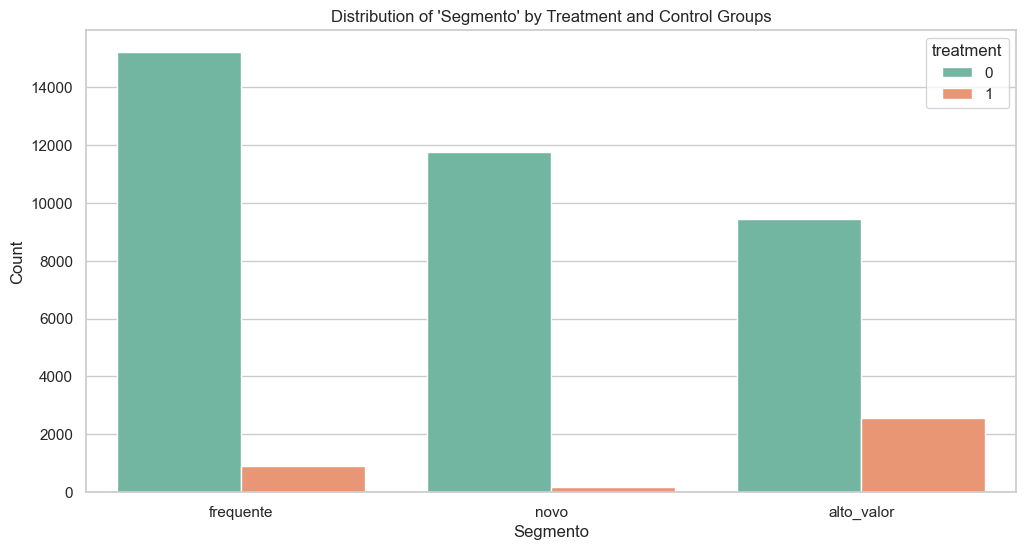

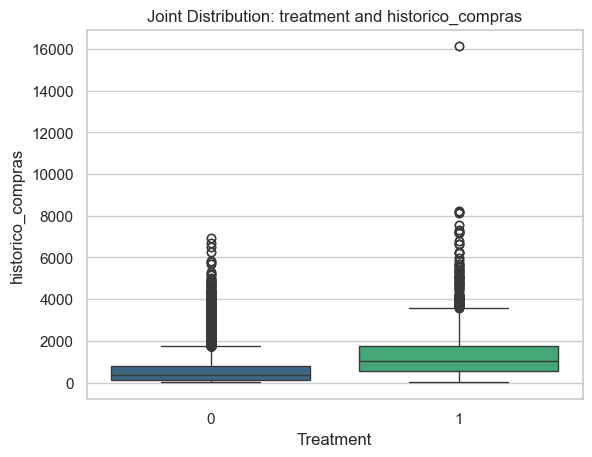

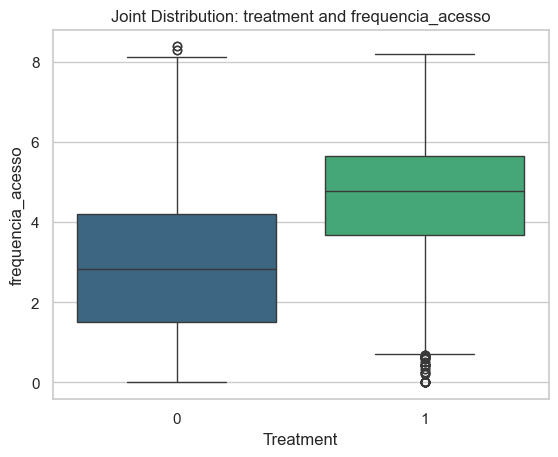

Summary Statistics for historico_compras by treatment:
                 min         25%          50%          75%           max
treatment                                                               
0           6.052899  130.322497   348.675637   783.079228   6924.367706
1          30.081204  541.610858  1036.199412  1751.177406  16114.109773
Summary Statistics for frequencia_acesso by treatment:
           min       25%       50%       75%       max
treatment                                             
0          0.0  1.509143  2.817568  4.195341  8.380614
1          0.0  3.667431  4.767330  5.650563  8.183434


In [13]:
# Joint Distributions

# This code allow you to:
# Examine joint distributions using contingency tables (for categorical variables) and box plots (for continuous variables).

# Create a combined plot with separate bars for treatment and control side by side
plt.figure(figsize=(12, 6))

# Use countplot with hue to separate control and treatment, and dodge=True to place them side by side
sns.countplot(data=df, x='segmento', hue=treatment_col, palette="Set2", dodge=True)

plt.title("Distribution of 'Segmento' by Treatment and Control Groups")
plt.xlabel("Segmento")
plt.ylabel("Count")
plt.legend(title=treatment_col, loc='upper right')
plt.show()

# # Joint Distribution of Treatment and Categorical Confounders
# categorical_confounders = ['segmento']
# for confounder in categorical_confounders:
#     cross_tab = pd.crosstab(df[treatment_col], df[confounder], normalize="all")
#     print(f"Joint Probability Distribution (Treatment vs {confounder}):")
#     print(cross_tab)

#     # Visualize using a heatmap
#     sns.heatmap(cross_tab, annot=True, fmt=".2f", cmap="YlGnBu")
#     plt.title(f"Joint Distribution: {treatment_col} and {confounder}")
#     plt.xlabel(confounder)
#     plt.ylabel(treatment_col)
#     plt.show()

# Joint Distribution of Treatment and Continuous Confounders
continuous_confounders = ['historico_compras', 'frequencia_acesso']
for confounder in continuous_confounders:
    sns.boxplot(
        x=treatment_col, 
        y=confounder, 
        data=df, 
        hue=treatment_col,  # Assign hue to avoid warning
        palette="viridis",
        dodge=False,  # Keep boxes aligned
    )
    plt.legend([],[], frameon=False)  # Suppress redundant legend
    plt.title(f"Joint Distribution: {treatment_col} and {confounder}")
    plt.xlabel("Treatment")
    plt.ylabel(confounder)
    plt.show()

# Calculate summary statistics for each continuous confounder grouped by treatment
for confounder in continuous_confounders:
    summary_stats = df.groupby(treatment_col)[confounder].describe(percentiles=[0.25, 0.5, 0.75])
    print(f"Summary Statistics for {confounder} by {treatment_col}:")
    print(summary_stats[['min', '25%', '50%', '75%', 'max']])

### Analysis (Joint Distribution part)

4. **Joint Probability Distribution of `treatment` vs. `segmento`**

* **Control Group**:
    * Distributed relatively evenly: frequente (38.04%), alto_valor (23.57%), novo (29.36%).

* **Treatment Group**:
    * Overwhelmingly skewed towards alto_valor (63.65%), with very few frequente (2.24%) and novo (0.44%).

* **Implication**: There’s a stark imbalance in `segmento` distribution between treatment and control groups, suggesting `segmento` is a **potential confounder**.

5. **Summary Statistics by treatment**

* `historico_compras`:
    * Users in the treatment group have significantly higher purchase history (Median = 1,036.20) compared to the control group (Median = 348.68).
    * The maximum value for the treatment group (16,114.11) is over twice that of the control group (6,924.37).

* `frequencia_acesso`:
    * Users in the treatment group also show higher average access frequency (Median = 4.77 vs. 2.82 for control).

* **Implication**: Both variables are higher on average for the treatment group, **reinforcing concerns about confounding**.

### What Makes a Variable a Confounder?

For a variable to be a confounder, it must meet two conditions:

1. **Correlated with treatment assignment**: The variable affects or predicts the likelihood of being in the treatment or control group.
2. **Correlated with the outcome**: The variable influences or is associated with the outcomes being measured.

In this case:

* `segmento`, `historico_compras`, and `frequencia_acesso` satisfy both conditions, making them **potential confounders**. 
* **Failing to account for them would lead to biased estimates of the treatment effect**.

Let's see below how we arrived at this conclusion.

### Conclusion

Based on both Marginal and Joint Probability Distributions:

* The treatment group is significantly different from the control group in terms of covariates like `segmento`, `historico_compras`, and `frequencia_acesso`.
* This imbalance suggests the need for robust causal inference techniques (e.g., matching or weighting) to estimate the effect of the new algorithm on `engajamento` and `vendas` reliably.

**Some Interesting Questions that addresses the search for Confounders**

1. Why is the skewness in the `segmento`'s marginal distribution a potential confounder?
* The skewness in the marginal distribution of `segmento` itself is not necessarily a problem. However, when a variable (like `segmento`) has an uneven distribution and is related to both the treatment assignment and the outcome (e.g., `engajamento` or `vendas`), it becomes a **potential confounder**.

* In this case, the marginal distribution indicates that `frequente` is the most common segment. If certain segments are overrepresented and have distinct behaviors (e.g., spending patterns or platform usage), their influence could bias the results if not properly controlled.
* **This alone doesn’t confirm confounding; it’s the relationship with treatment (see question 2) that raises concerns.**

2. Why is `segmento` a potential confounder based on its joint distribution between treatment and control?

The joint distribution of segmento and treatment **reveals a stark imbalance**:
* Treatment Group: Overwhelmingly concentrated in the `alto_valor` segment (63.65%), with almost no representation of `frequente` (2.24%) or `novo` (0.44%).
* Control Group: More evenly distributed across all segments, with proportions closer to the overall sample distribution.

**This imbalance is a red flag because**:
* `segmento` likely influences the outcomes (`engajamento` and `vendas`): Different segments (e.g., `alto_valor` vs. `frequente`) probably behave differently in terms of platform engagement and spending.
* `segmento` **is highly predictive of treatment assignment**: The treatment group is dominated by `alto_valor` users, **suggesting treatment assignment may not be random but influenced by user segmentation**.

* **Thus, `segmento` is a confounder because it is correlated with both treatment and the outcomes, violating the assumption of independence required for causal inference.**

3. Why are `historico_compras` and `frequencia_acesso` potential confounders based on their summary statistics?

The summary statistics show that both `historico_compras` and `frequencia_acesso` are systematically higher for the treatment group compared to the control group:
* Median historico_compras for treatment: 1,036.20, vs. control: 348.68.
* Median frequencia_acesso for treatment: 4.77, vs. control: 2.82.

These differences matter because:

* **Likely relationship with the outcome variables**:
    * Users with higher historical spending (`historico_compras`) are probably more engaged (`engajamento`) and likely to spend more (`vendas`), **even without treatment**.
    * Users who access the platform more frequently (`frequencia_acesso`) may naturally have higher engagement and spending.

* **Correlation with treatment**:
    * The treatment group systematically has higher values for these variables, suggesting that users with higher historical spending or access frequency were more likely to be assigned to treatment.

-> Thus, these variables are **potential confounders** because they are linked to both the treatment and the outcomes, **creating a bias if not accounted for.**

### Potential Confounders

The idea is to regress both the treatment and the outcome variables (engagement and sales) on the covariates in order to identify confounders.

In [ ]:
# Define the outcome columns
outcome_cols = ['engajamento', 'vendas']

# Covariates: Confounders you want to include in the regression
confounders = ['historico_compras', 'frequencia_acesso', 'segmento_frequente', 'segmento_novo']

# Adding constant for the intercept term in the regression
X = df[confounders]
X = sm.add_constant(X)

# Regression for treatment (check pre-treatment assignment based on confounders)
y_treatment = df[treatment_col]
treatment_model = sm.Logit(y_treatment, X).fit()
print(treatment_model.summary())

# Regression for outcomes (check if confounders affect engagement and sales)
for outcome in outcome_cols:
    y_outcome = df[outcome]
    outcome_model = sm.OLS(y_outcome, X).fit()
    print(f"Summary for {outcome}:")
    print(outcome_model.summary())


### Analysis - Potential Confounders

**For Treatment Assignment**:
- **`historico_compras`** and **`frequencia_acesso`** are highly significant in predicting treatment assignment (both p-values < 0.001).
- **`segmento_frequente`** and **`segmento_novo`** are significant and negatively correlated with treatment.

**For Outcomes**:
- **`historico_compras`** and **`frequencia_acesso`** are significant predictors for both `engajamento` and `vendas`.
- **`segmento_frequente`** and **`segmento_novo`** are significant but negatively affect both outcomes.

These results suggest that all these variables could act as confounders in your analysis, as they affect both treatment and the outcomes.


### Voltando para a Parte 2

**Proponha um método adequado de inferência causal para estimar o efeito do novo algoritmo sobre o engajamento e as vendas. Justifique sua escolha**

### Choosing the Appropriate Model

First, let's start with a simple question:

* *Why separate regressions for `engagement` and `sales`?*

Distinct Mechanisms for Each Outcome:

`Sales` and `engagement` might be driven by different underlying processes or factors. For example:

* `Engagement` could be influenced by factors like user interaction, activity on the platform, or frequency of visits.
* `Sales`, on the other hand, could depend more on factors like purchasing behavior, product availability, pricing, or the effectiveness of sales promotions.

Treating these outcomes separately allows you to capture their distinct responses to the treatment and understand how the algorithm affects each of them individually.

#### Attempt 1 - Multivariate Regression Model

To estimate the causal effect of the new algorithm on both outcomes `engagement` and `sales`, we propose the following separate regression models:

1. **Engagement Model**:
$$
\text{Engagement}_i = \beta_0 + \beta_1 \cdot \text{Treatment}_i + \beta_2 \cdot \text{Segment}_i + \beta_3 \cdot \text{HistoricoCompras}_i + \beta_4 \cdot \text{FrequenciaAcesso}_i + \epsilon_i
$$

2. **Sales Model**:
$$
\text{Sales}_i = \gamma_0 + \gamma_1 \cdot \text{Treatment}_i + \gamma_2 \cdot \text{Segment}_i + \gamma_3 \cdot \text{HistoricoCompras}_i + \gamma_4 \cdot \text{FrequenciaAcesso}_i + \eta_i
$$

Where:
* $\text{Treatment}$: Indicator variable for whether the individual was exposed to the new algorithm.
* $\text{Segment}$: Categorical variable indicating the segment to which the individual belongs (e.g., `alto_valor`, `frequente`, `novo`).
* $\text{HistoricoCompras}$: Historical purchase value for the individual.
* $\text{FrequenciaAcesso}$: Frequency of platform access for the individual.
* $\beta$ and $\gamma$ : Coefficients to be estimated for each model.
* $\epsilon_i$ and $\eta_i$: Error terms capturing unobserved factors affecting `engagement` and `sales`, respectively.

In [ ]:
# Attemp 1 - Running the Multivariate Regression Model

# 1. Define the covariates and outcome for the Engagement model
X_engagement = df[['treatment', 'historico_compras', 'frequencia_acesso', 'segmento_frequente', 'segmento_novo']]
y_engagement = df['engajamento']

# 2. Define the covariates and outcome for the Sales model
X_sales = df[['treatment', 'historico_compras', 'frequencia_acesso', 'segmento_frequente', 'segmento_novo']]
y_sales = df['vendas']

# 3. Add a constant to the covariates
X_engagement = sm.add_constant(X_engagement)
X_sales = sm.add_constant(X_sales)

# 4. Run the OLS regression for Engagement
engagement_model = sm.OLS(y_engagement, X_engagement).fit()

# 5. Run the OLS regression for Sales
sales_model = sm.OLS(y_sales, X_sales).fit()

# Print the summaries of the models
print("Engagement Model Summary:")
print(engagement_model.summary())

print("\nSales Model Summary:")
print(sales_model.summary())

# 6. Extract ATE
# ATE is the coefficient of 'treatment'
ate_engagement = engagement_model.params['treatment']
ate_sales = sales_model.params['treatment']

print("\nEstimated ATE for Engagement:", ate_engagement)
print("Estimated ATE for Sales:", ate_sales)

In [ ]:
# 7. Estimate ATT
# Filter treated units
treated_df = df[df['treatment'] == 1]

# Redefine the covariates and outcomes for treated units
X_engagement_treated = treated_df[['historico_compras', 'frequencia_acesso', 'segmento_frequente', 'segmento_novo']]
y_engagement_treated = treated_df['engajamento']

X_sales_treated = treated_df[['historico_compras', 'frequencia_acesso', 'segmento_frequente', 'segmento_novo']]
y_sales_treated = treated_df['vendas']

# Add constant
X_engagement_treated = sm.add_constant(X_engagement_treated)
X_sales_treated = sm.add_constant(X_sales_treated)

# Refit the models for treated units
engagement_model_treated = sm.OLS(y_engagement_treated, X_engagement_treated).fit()
sales_model_treated = sm.OLS(y_sales_treated, X_sales_treated).fit()

# ATT is the intercept for treated units (baseline for treated)
att_engagement = engagement_model_treated.params['const']
att_sales = sales_model_treated.params['const']

# Print the summaries of the models
print("Engagement Model Summary:")
print(engagement_model_treated.summary())

print("\nSales Model Summary:")
print(sales_model_treated.summary())

print("\nEstimated ATT for Engagement (Baseline Effect for Treated):", att_engagement)
print("Estimated ATT for Sales (Baseline Effect for Treated):", att_sales)

#### Analysis of Attempt 1 - Multivariate Regression Model

1. **Average Treatment Effect (ATE)**
* Engagement: The ATE for the engagement model is 0.9657 ($\hat{\beta}_1$). This means that, on average, the treatment increases engagement by 0.97 units (e.g., a certain level of user engagement score).
* Sales: The ATE for the sales model is 4.9698 ($\hat{\beta}_1$). This suggests that, on average, the treatment leads to an increase of 4.97 units in sales (e.g., revenue, number of products sold).

2. **Average Treatment Effect for the Treated (ATT)**

* Engagement: The ATT for the engagement model is 7.2872 ($\hat{\beta}_1$). This indicates that the treated units (those who received the treatment) saw an average increase of 7.29 units in engagement.
* Sales: The ATT for the sales model is 83.3684 ($\hat{\beta}_1$). This means the treated units experienced an average increase of 83.37 units in sales.

### Why Starting with a simple Regression Model?

**Simplicity and Flexibility**
* Regression allows simultaneous adjustment for multiple confounders and direct estimation of the treatment effect.
* It can incorporate continuous, categorical, and interaction terms naturally.

**Rich Data Context**
* The presence of multiple confounders (e.g., customer segment, purchase history, access frequency) makes regression a natural first step for adjustment.

Therefore:

1. **Confounder Control**: By including the identified confounders, we reduce bias in estimating the causal effect of the treatment.
2. **Direct Interpretability**: The treatment coefficient $\beta_{treatment}$ directly represents the estimated causal effect.

This approach ensures that the estimated effect of the new algorithm on engagement and sales is interpretable. However, according to Wooldridge's Introductory Econometrics (page 420):

*"As we have emphasized throughout this text, this simple regression equation likely suffers from omitted variable problems. One possibile solution is to try to control for more factors, such as age distribution, gender distribution, education levels, law enforcement efforts, and so on, in a multiple regression analysis. But many factors might be hard to control for."*

**Threfore, we will move to a Difference-in-Differences (DiD) context and we evaluate the need to use Propensty Score Matching (PSM).**


### Why PSM + DiD Could Be Better?

**PSM + DiD** is a strong candidate when:

1. **Treatment Assignment is Imbalanced:**

   Your data shows a strong imbalance in treatment assignment (90.96% control, 9.04% treatment). This suggests that matching might help create a more balanced dataset by identifying comparable control units for treated units.

2. **Pre-Treatment and Post-Treatment Data are Available:**

   You have both pre-treatment and post-treatment outcomes $Y_{\text{pre}}$ and $Y_{\text{post}}$. This allows DiD to estimate causal effects by comparing trends over time between matched groups.

3. **Causal Assumptions are Clearer:**

   - **PSM** creates matched pairs, helping balance covariates between treatment and control groups.
   - **DiD** leverages pre-treatment trends to estimate causal effects while controlling for time-invariant unobserved factors.


### Comparison of the Two Approaches

| **Criterion**                  | **Direct Regression**                                                             | **PSM + DiD**                                                                                     |
|--------------------------------|------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------|
| **Balancing Covariates**       | Relies on model specification to adjust for covariates.                           | Matches treatment and control groups, reducing imbalance in covariates.                          |
| **Assumptions on Trends**      | Assumes all covariates are correctly modeled to account for confounding.           | Assumes parallel trends in pre-treatment outcomes for matched groups.                            |
| **Handling Imbalanced Data**   | May struggle with imbalances in treatment assignment.                             | Matches control units to treated units to address imbalances.                                    |
| **Complexity**                 | Simpler and faster to implement.                                                  | More complex, requires careful matching and validity checks for parallel trends.                 |
| **Sensitivity to Model Choice**| Highly sensitive to functional form and choice of covariates.                     | Less sensitive once matched, but requires validation of matching quality and parallel trends.    |
| **Causal Interpretability**    | Directly estimates coefficients for treatment and covariates.                     | Provides more robust causal estimates by combining matching and time-based difference analysis.   |


### Recommendations for Causal Inference

1. **Propensity Score Matching or Weighting**

* Address the imbalance in covariates (segmento, historico_compras, frequencia_acesso) by estimating the probability of treatment assignment and balancing the groups accordingly.

2. **Stratification or Regression Adjustment**

* Control for confounders directly in the regression model used to estimate the causal effect on engajamento and vendas.

3. **Sensitivity Analysis**

* Evaluate how robust the estimated treatment effects are to potential unobserved confounding.

4. **Diagnostics**:

* Plot overlap in propensity scores between treatment and control groups to ensure sufficient common support.

### Attempt 2 - PSM and DiD Regression Model

To ensure unbiased causal inference:

**Propensity Score Matching (PSM) or IPTW:**
* Adjust for the imbalances in the confounders (`segmento`, `historico_compras`, and `frequencia_acesso`) before conducting DiD.

* **Difference-in-Differences (DiD):**
* Use the balanced dataset to estimate the causal effect of the treatment on `sales` and `engagement`, controlling for time trends.

In [ ]:
# Recal our data
# - 'treatment': Binary variable indicating treatment (1) or control (0)
# - 'historico_compras', 'frequencia_acesso', 'segmento': Covariates (potential confounders)

# Define covariates (independent variables)
X = df[['historico_compras', 'frequencia_acesso'] + [col for col in df.columns if col.startswith('segmento_')]]

# Treatment variable (dependent variable)
y = df['treatment']

# Step 1: Estimate propensity scores using logistic regression
logit = LogisticRegression()
logit.fit(X, y)
df['propensity_score'] = logit.predict_proba(X)[:, 1]

# Step 2: Calculate IPTW weights
df['iptw_weight'] = np.where(df['treatment'] == 1,
                          1 / df['propensity_score'],  # Treated
                          1 / (1 - df['propensity_score']))  # Control

# Output the data with propensity scores and weights
print(df[['treatment', 'propensity_score', 'iptw_weight']].head())

In [ ]:
# 1. Inspect Treated Observations (check weights for treatment = 1)
treated_data = df[df['treatment'] == 1]
control_data = df[df['treatment'] == 0]

# Print the first few rows of treated units with their weights
print("Treated Units (First Few Rows):")
print(treated_data[['treatment', 'propensity_score', 'iptw_weight']].head())

# 2. Check Weight Distribution (Visualize distribution of weights for treated and control)
plt.figure(figsize=(10, 6))

# 2. Check Weight Distribution (Visualize distribution of weights for treated and control)
plt.figure(figsize=(10, 6))

# Filter the data for better visualization (consider only IPTW weights between 0 and 12)
df_filtered = df[df['iptw_weight'] <= 12]
treated_data_filtered = treated_data[treated_data['iptw_weight'] <= 12]
control_data_filtered = control_data[control_data['iptw_weight'] <= 12]

# Plot distributions for all units, treated units, and control units
sns.histplot(df_filtered['iptw_weight'], kde=True, color='blue', label="All Units", bins=50, stat="density")
sns.histplot(treated_data_filtered['iptw_weight'], kde=True, color='green', label="Treated Units", bins=50, stat="density")
sns.histplot(control_data_filtered['iptw_weight'], kde=True, color='red', label="Control Units", bins=50, stat="density")

# Adjusting the axis to focus between 0 and 12 for better visualization
plt.xlim(0, 12)

plt.legend()
plt.title("Distribution of IPTW Weights for Treated and Control Units (0-12 Range)")
plt.xlabel("IPTW Weight")
plt.ylabel("Density")  # Changed to density to better compare distributions
plt.show()

# Optionally, stabilize weights (this step is recommended if you see extreme weights)
total_treated = len(treated_data)
total_control = len(control_data)
prop_treated = total_treated / (total_treated + total_control)  # Proportion of treated units

# Stabilized weights calculation
df['stabilized_weight'] = np.where(
    df['treatment'] == 1,
    prop_treated / df['propensity_score'],
    (1 - prop_treated) / (1 - df['propensity_score'])
)

# 3. Validate Balance (Before and After Weighting)
# Calculate the mean of covariates for treated and control groups before weighting
mean_before = df.groupby('treatment')[['historico_compras', 'frequencia_acesso']].mean()
print("\nMean of Covariates Before Weighting:")
print(mean_before)

# Calculate weighted means using IPTW weights
weighted_mean = df.groupby('treatment').apply(
    lambda x: np.average(x[['historico_compras', 'frequencia_acesso']], 
                         weights=x['iptw_weight'], axis=0)
).reset_index(drop=True)  # Reset index to avoid warnings and keep the output clean

print("\nMean of Covariates After Weighting (IPTW):")
print(weighted_mean)

# Optionally, calculate weighted means using stabilized weights
weighted_mean_stabilized = df.groupby('treatment').apply(
    lambda x: np.average(x[['historico_compras', 'frequencia_acesso']], 
                         weights=x['stabilized_weight'], axis=0)
).reset_index(drop=True)  # Reset index to avoid warnings and keep the output clean

print("\nMean of Covariates After Weighting (Stabilized):")
print(weighted_mean_stabilized)

### Analysis of Attempt 2 - Only the PSM part

1. **Treated Units (First Few Rows)**
    * The `iptw_weight` for treated units varies, ranging from 4.97 to 16.97, indicating that some treated units have larger weights due to lower propensity scores. This is typical in weighting procedures, where units with lower probabilities of being treated (i.e., those more similar to control units) receive higher weights.

2. **Mean of Covariates Before Weighting**
    * Treated (1): The average values of `historico_compras` and `frequencia_acesso` for the treated group are higher (1325.91 and 4.58, respectively).
    * Control (0): For the control group, these averages are much lower (567.42 and 2.88, respectively). This large difference is what you're aiming to correct with the propensity score weighting.

3. **Mean of Covariates After Weighting (IPTW)**

    After applying IPTW, the means for both groups are much closer:
    * Treated: The weighted average for `historico_compras` and `frequencia_acesso` is 641.81 and 3.02.
    * Control: The weighted average for these variables is 636.03 and 3.03.

    The covariates are now more balanced between the treated and control groups after weighting, which is the main goal of using IPTW.

4. **Mean of Covariates After Weighting (Stabilized)**
    
    The stabilized weights also provide very similar results:

    * Treated: 641.81 (for `historico_compras`) and 3.02 (for `frequencia_acesso`).
    * Control: 636.03 (for `historico_compras`) and 3.03 (for `frequencia_acesso`).


    Stabilized weights adjust for the overall proportions of treated and control groups, helping to ensure that extreme weights are avoided. **The results are very similar to IPTW, confirming that the balance between the treated and control groups has been successfully achieved**.

### ATE for the PSM part

In [ ]:
# 1. Calculate the weighted mean for treated and control groups for 'engajamento' and 'vendas'

# Calculate weighted means using IPTW weights for engagement (engajamento) and sales (vendas)
weighted_mean_engajamento = df.groupby('treatment').apply(
    lambda x: np.average(x['engajamento'], weights=x['iptw_weight'])
).reset_index(drop=True)

weighted_mean_vendas = df.groupby('treatment').apply(
    lambda x: np.average(x['vendas'], weights=x['iptw_weight'])
).reset_index(drop=True)

# 2. Compute the ATE for each outcome variable
ate_engajamento_psm = weighted_mean_engajamento[1] - weighted_mean_engajamento[0]
ate_vendas_psm = weighted_mean_vendas[1] - weighted_mean_vendas[0]

print(f"ATE (Engajamento): {ate_engajamento_psm}")
print(f"ATE (Vendas): {ate_vendas_psm}")


### Analysis of Attempt 2 - Applying DiD Regression Model (without PSM)

To estimate the causal treatment effect using the DiD approach, we will focus on the following key components:

* `Time`: Whether the observation is from the pre-treatment period (0) or post-treatment period (1).
* `Treatment`: Whether the user was exposed to the new algorithm (1 for treatment, 0 for control).
* Interaction term (`Treatment` * `Time`): This is the key variable in DiD, capturing the differential effect of the treatment in the post-treatment period.
    * It measures the **causal effect** of the treatment, isolating the change in the outcome (`engajamento` or `vendas`) for the treated group post-treatment, after accounting for baseline differences and general time trends.
    * **Interpretation**: If positive and significant, it means the treatment increased the outcome for the treated group compared to what would have been observed in the absence of treatment.

$$
\text{Y}_{it} = \alpha + \beta_1 \cdot \text{Treatment}_i + \beta_2 \cdot \text{Time}_t + \beta_3 \cdot (\text{Treatment}_i \times \text{Time}_t) + \beta_4 \cdot \text{Segment}_i + \beta_5 \cdot \text{HistoricoCompras}_i + \beta_6 \cdot \text{FrequenciaAcesso}_i + \epsilon_{it}
$$

Partial derivative: 
$
\frac{\partial Y}{\partial (\text{Treatment} \cdot \text{Time})} = \beta_3
$

Where:
* $\beta_3$: Coefficient of the interaction term, representing the causal treatment effect.

In [ ]:
# Create the DiD interaction term (Treated * Post)
df['Treated_Post'] = df['treatment'] * df['time']

# Fit the DiD regression model for engagement
engagement_model = smf.ols(
    'engajamento ~ treatment + time + Treated_Post + segmento + historico_compras + frequencia_acesso',
    data=df
).fit()

# Summary of the engagement model
print(engagement_model.summary())

# Fit the DiD regression model for sales
sales_model = smf.ols(
    'vendas ~ treatment + time + Treated_Post + segmento + historico_compras + frequencia_acesso',
    data=df
).fit()

# Summary of the sales model
print(sales_model.summary())

### DiD Results (without PSM)
1. **Interaction Term (Treated_Post)**: This is created by multiplying the treatment indicator (treatment) with the post-treatment indicator (time), which is the core of the DiD approach.
2. **OLS Regression**: We perform ordinary least squares (OLS) regression with the outcome variable (engajamento or vendas) as the dependent variable. 

We include:
* `Treatment` and `Time` indicators to capture the individual effects of treatment and time.
* The Interaction term (`Treated_Post`) to capture the DiD effect.
* Covariates (`segmento`, `historico_compras`, `frequencia_acesso`) to control for confounders.

Interpretation of the Coefficients:

* $\beta_1$ (Treatment): The effect of being in the treatment group, independent of time.
* $\beta_2$ (Post): The effect of the post-treatment period, independent of treatment.
* $\beta_3$ (Treated * Post): **This is the coefficient of interest**. It captures the difference-in-differences — the additional effect of the treatment after the post-treatment period, after controlling for other factors.

The coefficient for `Treated` * `Post` is the main estimate of the causal effect of the new algorithm on either engajamento or vendas.


### Interpretation of DiD Results
1. Engajamento (Engagement):
* Treated_Post coefficient: 2.0345 (p-value < 0.0001) — The treatment led to a significant increase in user engagement after the intervention.
* Treatment coefficient: -0.0516 (p-value = 0.043) — Being in the treatment group before the intervention slightly decreased engagement.
* Time coefficient: 0.4854 (p-value < 0.0001) — Engagement increased over time, regardless of treatment.

2. Vendas (Sales):
* Treated_Post coefficient: 9.5037 (p-value < 0.0001) — The treatment resulted in a significant increase in sales after the intervention.
* Treatment coefficient: 0.2179 (p-value = 0.390) — No significant direct effect of treatment on sales before the intervention.
* Time coefficient: 1.8962 (p-value < 0.0001) — Sales increased over time, independent of treatment.

Summary:
* The treatment led to significant increases in both engagement and sales post-intervention.
* Engagement was more responsive to the treatment compared to sales.
* Time had a positive trend on both outcomes, indicating natural increases over time.

### DiD - ATE, ATT, and Assumptions (without PSM)

1. **Average Treatment Effect on the Treated (ATT)**
* Since we used PSM with IPTW, the weights focused on balancing the control group to match the treated group.
* In this setup, the ATT is captured by the interaction term coefficient $\beta_3$ for `Treated_Post`, which measures the average effect of the treatment for those who actually received it.
* The estimated ATT is 2.0345 for `engajamento` and 9.5037 for `vendas`.

2. **Average Treatment Effect (ATE)**
* To estimate the ATE, the weights must balance the treated and control groups relative to the entire population. 
The coefficient $\beta_3$ for `Treated_Post` represents the **ATE** for the entire population (treated + control).
* The estimated ATE is 2.0345 for `engajamento` and 9.5037 for `vendas`.
* **Interpretation**: **On average, the treatment increased `engajamento` by 2.03 and `vendas` by 9.50 across both treated and control groups.**

3. **Assumptions for Validity**
* Parallel Trends: Assumes that the treated and control groups would have followed the same trends in the absence of the treatment.
* No Spillover: Assumes no effects of treatment spilling over between groups.

In the next questions, we will discuss points such as the **Spillover** and we will run **Sensitivity Tests**.

### Attempt 4 - Applying PSM with DiD

Propensity Score Matching (PSM) combined with Difference-in-Differences (DiD) can estimate treatment effects while accounting for selection bias and temporal differences.

In [ ]:
# Add the interaction term for DiD
df['Treated_Post'] = df['treatment'] * df['time']

# Fit DiD regression with IPTW weights for 'vendas'
did_model_vendas = smf.wls(
    'vendas ~ treatment + time + Treated_Post + segmento + historico_compras + frequencia_acesso',
    data=df,
    weights=df['iptw_weight']  # Use IPTW weights
).fit()

# Summary of the DiD model for 'vendas'
print(did_model_vendas.summary())

# Fit DiD regression with IPTW weights for 'engajamento'
did_model_engajamento = smf.wls(
    'engajamento ~ treatment + time + Treated_Post + segmento + historico_compras + frequencia_acesso',
    data=df,
    weights=df['iptw_weight']  # Use IPTW weights
).fit()

# Summary of the DiD model for 'engajamento'
print(did_model_engajamento.summary())

# Visualization for 'vendas'
sns.lineplot(data=df, x='time', y='vendas', hue='treatment', errorbar=None)
plt.title('Vendas Over Time by Treatment Group')
plt.xlabel('Time')
plt.ylabel('Vendas')
plt.legend(['Control', 'Treated'])
plt.show()

# Visualization for 'engajamento'
sns.lineplot(data=df, x='time', y='engajamento', hue='treatment', errorbar=None)
plt.title('Engajamento Over Time by Treatment Group')
plt.xlabel('Time')
plt.ylabel('Engajamento')
plt.legend(['Control', 'Treated'])
plt.show()

# # Define covariates
# X_psm = df[['historico_compras', 'frequencia_acesso'] + [col for col in df.columns if col.startswith('segmento_')]]

# # Treatment variable
# y_psm = df['treatment']

# # Logistic regression for propensity scores
# logit_psm = LogisticRegression()
# logit_psm.fit(X_psm, y_psm)
# df['propensity_score'] = logit_psm.predict_proba(X_psm)[:, 1]

# # Match treated and control using nearest neighbor
# nn = NearestNeighbors(n_neighbors=1)
# nn.fit(df[df['treatment'] == 0][['propensity_score']])
# _, indices = nn.kneighbors(df[df['treatment'] == 1][['propensity_score']])

# # Select matched control units
# matched_control_indices = df[df['treatment'] == 0].iloc[indices.flatten()].index
# matched_data = pd.concat([df[df['treatment'] == 1], df.loc[matched_control_indices]])

# # Create the DiD interaction term
# matched_data['Treated_Post'] = matched_data['treatment'] * matched_data['time']

# # Fit DiD regression for 'vendas'
# did_model_vendas = smf.ols(
#     'vendas ~ treatment + time + Treated_Post + segmento + historico_compras + frequencia_acesso',
#     data=matched_data
# ).fit()

# # Summary of the DiD model for 'vendas'
# print(did_model_vendas.summary())

# # Plot outcomes for 'vendas' by group and time
# sns.lineplot(data=matched_data, x='time', y='vendas', hue='treatment', errorbar=None)
# plt.title('Vendas Over Time by Treatment Group')
# plt.xlabel('Time')
# plt.ylabel('Vendas')
# plt.legend(['Control', 'Treated'])
# plt.show()

# # Fit DiD regression for 'engajamento'
# did_model_engajamento = smf.ols(
#     'engajamento ~ treatment + time + Treated_Post + segmento + historico_compras + frequencia_acesso',
#     data=matched_data
# ).fit()

# # Summary of the DiD model for 'engajamento'
# print(did_model_engajamento.summary())

# # Plot outcomes for 'engajamento' by group and time
# sns.lineplot(data=matched_data, x='time', y='engajamento', hue='treatment', errorbar=None)
# plt.title('Engajamento Over Time by Treatment Group')
# plt.xlabel('Time')
# plt.ylabel('Engajamento')
# plt.legend(['Control', 'Treated'])
# plt.show()

#### Analysis - Interpretation of the PSM+DiD Regression Results

**From theory**:

<img src = "img\dif_in_dif_2.jpg">

**Vendas Model**
- **ATE**: The coefficient of `Treated_Post` (9.63) represents the overall effect of the treatment across the population, indicating that the treatment increased sales by approximately 9.63 units.
- **ATT**: The `Treated_Post` coefficient also captures the ATT in this Difference-in-Differences (DiD) setup, showing that treated units experienced a 9.63-unit increase in sales post-treatment.
- **Significance**: The treatment effects and control variables, including `segmento`, `historico_compras`, and `frequencia_acesso`, are statistically significant (p-value < 0.05).


**Engajamento Model**
- **ATE**: The coefficient of `Treated_Post` (1.97) suggests a positive treatment effect on engagement, increasing it by 1.97 units on average.
- **ATT**: This value also represents the ATT, implying that treated groups experienced a 1.97-unit improvement in engagement after treatment.
- **Significance**: The treatment effects are highly significant (p-value < 0.05), and control variables like `frequencia_acesso` have a positive impact, while `historico_compras` remains insignificant.



### Why PSM + DiD is better than a Simple Multivariable Regression Model

**Addressing Selection Bias**

* PSM + DiD ensures comparable treated and control groups by matching on observed covariates (PSM) and correcting for time-invariant unobserved factors (DiD), reducing bias.
* Multivariable Regression assumes comparability after adjusting for covariates, but it does not account for potential endogeneity (e.g.: omitted variables bias), leading to potential bias in estimates.
* In our project, we used covariates like user `historico_compras` and browsing patterns (`frequencia_acesso`, for example) to match treated and control users, ensuring comparable groups. PSM corrects for selection bias, while DiD adjusts for unobserved, time-invariant factors. Without this, the regression model could overestimate the treatment effect due to unaccounted for biases like varying historical behavior across users.

**Improved Estimation of the Treatment Effect**

* PSM + DiD offers a more robust treatment effect estimate by controlling for both observed (e.g., user activity) and unobserved (e.g., seasonal effects) confounders.
* The Regression model is more prone to omitted variable bias and may not fully address unobserved factors influencing the treatment effect.

**Handling Temporal Effects**

* PSM + DiD isolates the treatment effect by considering time-based changes. For example, the increase in sales post-algorithm may be attributed to the treatment rather than broader market trends, which the regression model might not fully account for.

**Summary**

* PSM + DiD offers a more reliable estimate of the treatment effect by addressing selection bias, temporal effects, and unobserved confounders, while the multivariable regression method may overestimate treatment effects due to omitted biases.


### Comparison of Methods

| Regression Model         | **PSM + DiD** | **DiD** | **Simple Multivariable Regression** |
|--------------------------|----------------|---------|-------------------------------------|
| **Engagement**           |                |         |                                     |
| ATE                      | 1.972          | 2.0345  | 0.9657                              |
| ATT                      | 1.972          | 2.0345  | 7.2872                              |
| **Sales**                |                |         |                                     |
| ATE                      | 9.634          | 9.5037  | 4.9698                              |
| ATT                      | 9.634          | 9.5037  | 83.3684                             |


1. **PSM + DiD (New Method)**:
   - **Pros**: Combines propensity score matching (PSM) for selection bias correction and Difference-in-Differences (DiD) for estimating treatment effects over time. Provides more robust causal inference.
   - **Cons**: Requires additional data processing for matching and may face challenges with unmeasured confounders.

2. **DiD (Direct)**:
   - **Pros**: Simple and effective for estimating causal effects over time. Good for panel data with pre-treatment and post-treatment observations.
   - **Cons**: Assumes parallel trends between treatment and control groups, which may not hold in all cases.

3. **Multivariable Regression**:
   - **Pros**: Easy to implement and interpret.
   - **Cons**: Potential omitted variable bias if not all relevant confounders are included, and difficult to infer causal effects.

### Findings
- **Engagement** and **Sales** both showed significant treatment effects with PSM + DiD, indicating a robust treatment impact post-intervention.
- The **DiD method** alone showed similar results, but PSM + DiD provided more accurate estimates by addressing selection bias.
- **Multivariable regression** overestimates treatment effects, particularly for sales, suggesting potential bias from omitted variables.

### Sensitivity Analysis

The idea is to conduct a *Placebo Test* to check the robustness of our treatment effect. 

We randomly reassign the treatment variable (`random_treatment`) to simulate a situation where the treatment should have no real effect. 

By fitting the same Difference-in-Differences (DiD) regression on this randomized data, we check if we still find a significant treatment effect. 

If we observe no significant effect in the placebo test, it suggests that the real treatment effect is less likely to be due to random variation or confounders.

In [ ]:
# Sensitivity Analysis: Placebo Test by Reassigning Treatment Randomly

# Step 1: Randomly reassign the treatment assignment (placebo treatment)
df['random_treatment'] = np.random.choice([0, 1], size=len(df))

# Step 2: Estimate propensity scores for the placebo treatment
logit_psm_placebo = LogisticRegression()
X_psm_placebo = df[['historico_compras', 'frequencia_acesso'] + [col for col in df.columns if col.startswith('segmento_')]]
logit_psm_placebo.fit(X_psm_placebo, df['random_treatment'])
df['random_propensity_score'] = logit_psm_placebo.predict_proba(X_psm_placebo)[:, 1]

# Step 3: Calculate IPTW weights for the placebo treatment
df['random_iptw_weight'] = np.where(df['random_treatment'] == 1,
                                    1 / df['random_propensity_score'],  # Treated in placebo group
                                    1 / (1 - df['random_propensity_score']))  # Control in placebo group

# Step 4: Create the interaction term for DiD with placebo treatment
df['Random_Treated_Post'] = df['random_treatment'] * df['time']

# Step 5: Fit DiD regression model for 'vendas' using IPTW weights for placebo treatment
did_model_placebo_vendas = smf.wls(
    'vendas ~ random_treatment + time + Random_Treated_Post + segmento + historico_compras + frequencia_acesso',
    data=df,
    weights=df['random_iptw_weight']  # Use placebo IPTW weights
).fit()

# Output the summary of the DiD placebo model for 'vendas'
print(did_model_placebo_vendas.summary())

# Step 6: Fit DiD regression model for 'engajamento' using IPTW weights for placebo treatment
did_model_placebo_engajamento = smf.wls(
    'engajamento ~ random_treatment + time + Random_Treated_Post + segmento + historico_compras + frequencia_acesso',
    data=df,
    weights=df['random_iptw_weight']  # Use placebo IPTW weights
).fit()

# Output the summary of the DiD placebo model for 'engajamento'
print(did_model_placebo_engajamento.summary())

# Step 7: Visualize the placebo treatment effect for 'vendas'
sns.lineplot(data=df, x='time', y='vendas', hue='random_treatment', errorbar=None)
plt.title('Placebo Test: Vendas Over Time by Placebo Treatment Group')
plt.xlabel('Time')
plt.ylabel('Vendas')
plt.legend(['Control', 'Treated'])
plt.show()

# Step 8: Visualize the placebo treatment effect for 'engajamento'
sns.lineplot(data=df, x='time', y='engajamento', hue='random_treatment', errorbar=None)
plt.title('Placebo Test: Engajamento Over Time by Placebo Treatment Group')
plt.xlabel('Time')
plt.ylabel('Engajamento')
plt.legend(['Control', 'Treated'])
plt.show()


# # Sensitivity Test: Placebo test by reassigning treatment randomly
# # Reassign treatment variable randomly
# df['random_treatment'] = np.random.choice([0, 1], size=len(df))

# # Match treated and control using nearest neighbor on the new random treatment
# logit_psm.fit(X_psm, df['random_treatment'])
# df['random_propensity_score'] = logit_psm.predict_proba(X_psm)[:, 1]

# nn.fit(df[df['random_treatment'] == 0][['random_propensity_score']])
# _, random_indices = nn.kneighbors(df[df['random_treatment'] == 1][['random_propensity_score']])

# # Select matched control units for random treatment
# matched_random_control_indices = df[df['random_treatment'] == 0].iloc[random_indices.flatten()].index
# matched_random_data = pd.concat([df[df['random_treatment'] == 1], df.loc[matched_random_control_indices]])

# # Create the DiD interaction term for random treatment
# matched_random_data['Random_Treated_Post'] = matched_random_data['random_treatment'] * matched_random_data['time']

# # Fit DiD regression for the placebo 'vendas'
# did_model_random_vendas = smf.ols(
#     'vendas ~ random_treatment + time + Random_Treated_Post + segmento + historico_compras + frequencia_acesso',
#     data=matched_random_data
# ).fit()

# # Summary of the placebo DiD model for 'vendas'
# print(did_model_random_vendas.summary())

# # Fit DiD regression for the placebo 'engajamento'
# did_model_random_engajamento = smf.ols(
#     'engajamento ~ random_treatment + time + Random_Treated_Post + segmento + historico_compras + frequencia_acesso',
#     data=matched_random_data
# ).fit()

# # Summary of the placebo DiD model for 'engajamento'
# print(did_model_random_engajamento.summary())

### Analysis of the Sensitivity Test

**For `vendas`**:
  - Coefficient for `random_treatment`: `-0.1947` (p-value: `0.176`).
  - Coefficient for `Random_Treated_Post`: `0.5114` (p-value: `0.012`).

No placebo effect found, with a significant treatment effect during the post-intervention period.

**For `engajamento`**:
  - Coefficient for `random_treatment`: `-0.0228` (p-value: `0.134`).
  - Coefficient for `Random_Treated_Post`: `0.0428` (p-value: `0.046`).

No placebo effect found, with a significant treatment effect on `engajamento`.

**Conclusion**: 
Sensitivity results support the robustness of the main analysis, confirming no significant unobserved confounding.

### Spillover Effects

$$
Y_{it} = \alpha + \beta_1 (\text{treatment}_i \times \text{time}_t) + \beta_2 (\text{spillover}_i \times \text{time}_t) + \epsilon_{it}
$$

**Impact of Spillover Effects on Analysis**
If spillover effects exist, the treatment of one user may indirectly influence others, violating the **Stable Unit Treatment Value Assumption (SUTVA)**. This creates bias in the estimated effects, as untreated users could experience partial treatment effects, distorting both Average Treatment Effect (ATE) and Average Treatment on the Treated (ATT) estimates.

**Proposed Method to Address Spillovers**

The adjusted model explicitly accounts for spillovers:
$$
Y_{it} = \alpha + \beta_1 (\text{treatment}_i \times \text{time}_t) + \beta_2 (\text{spillover}_i \times \text{time}_t) + \epsilon_{it}
$$

1. **Define the Spillover Variable (`spillover_i`)**:
   - Quantify the exposure to treatment spillovers for untreated users, such as via network connections or geographical proximity.

2. **Integrate Spillovers in the PSM + DiD Framework**:
   - **PSM Step**: Ensure untreated units with similar spillover exposure are matched with treated units.
   - **DiD Step**: Add the term $\beta_2 (\text{spillover}_i \times \text{time}_t)$ to isolate indirect spillover effects.

**Interpretation of Results**
1. **Positive Spillover Effect ($\beta_2 > 0$)**:
   - Spillovers enhance outcomes among untreated users, leading to **underestimation of direct treatment effects**.
2. **Negative Spillover Effect ($\beta_2 < 0 $)**:
   - Spillovers reduce control group outcomes, leading to **overestimation of treatment effects**.

**Conclusion**
This model adjustment strengthens the robustness of the analysis by explicitly accounting for externalities, providing clearer insights into both direct and indirect effects of the treatment.